<a href="https://colab.research.google.com/github/dixondanty/AI-ML-internship/blob/main/day7/linear_regression_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing


In [7]:
housing=fetch_california_housing()
data=fetch_california_housing(as_frame=True).frame

In [9]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
data.shape

(20640, 9)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [12]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


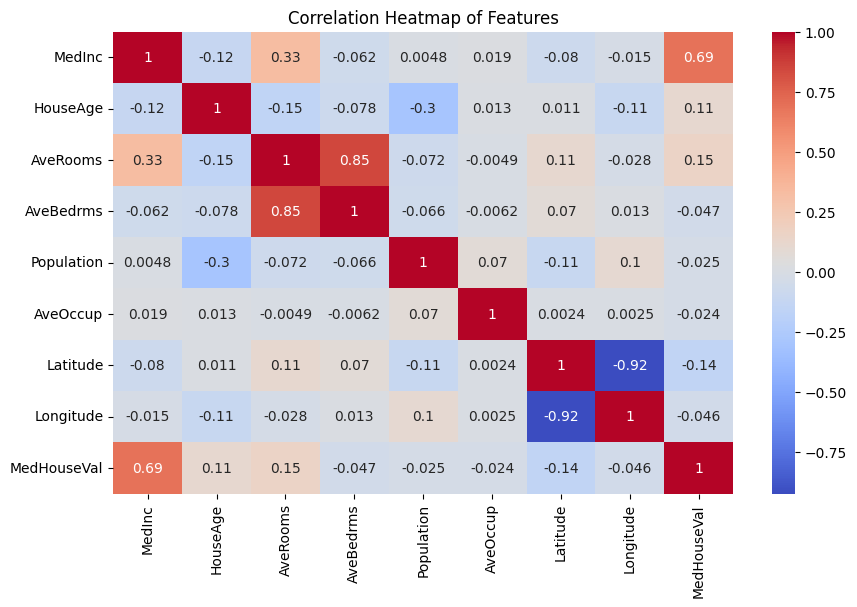

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()


In [14]:
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

In [143]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [144]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16512, 8)
(4128, 8)


In [145]:
print(X_train_scaled)

[[ 2.28655275e+00 -1.00374733e+00  7.31500047e-01 ... -1.31009118e-03
   7.44083934e-01 -1.15694555e+00]
 [ 1.57815957e+00  1.06417939e+00  3.90085610e-01 ... -1.93935864e-02
  -7.89623345e-01  7.17671737e-01]
 [-1.39683848e+00  6.66501172e-01 -9.84306177e-01 ... -2.14451570e-02
  -7.05456482e-01  6.57683983e-01]
 ...
 [-1.10063683e+00  1.30278631e+00 -6.83558153e-01 ...  1.07212741e-01
  -7.56891787e-01  6.92676839e-01]
 [ 3.95358266e-01  1.54139324e+00 -1.61944316e-02 ... -8.40989185e-02
  -6.96104609e-01  5.77700313e-01]
 [-3.43114181e-01 -1.48096118e+00 -1.86293016e-02 ... -2.73122396e-02
   1.78681785e+00 -1.91179144e+00]]


In [146]:
model=LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [147]:
y_pred=model.predict(X_test_scaled)

In [148]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Intercept: 2.061741065285852
Coefficients: [ 0.81081691  0.11474384 -0.25448539  0.30120387 -0.00299649 -0.03905888
 -0.91702342 -0.88615724]
Mean Squared Error: 0.512127858902474
R² Score: 0.6253780179145404


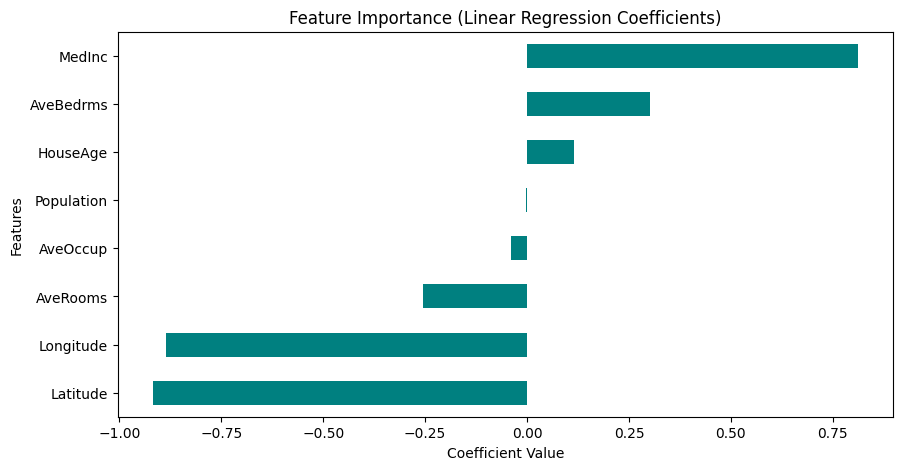

In [149]:
feature_importance = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(10,5))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

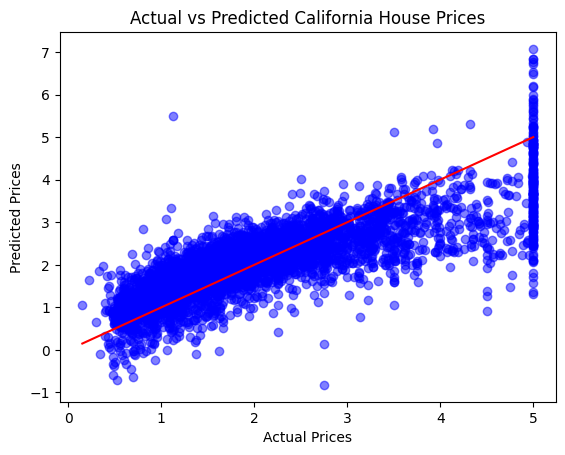

In [150]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted California House Prices')
plt.show()

In [152]:
sample_input = np.array([[8, 20, 5, 1, 1000, 3, 34, -118]])
sample_input_scaled = scaler.transform(sample_input)

predicted_value = model.predict(sample_input_scaled)[0]
print(f"\nPredicted Median House Value: ${predicted_value * 100000:.2f}")


Predicted Median House Value: $374197.80


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
